# Anomaly Detection with KMeans Clustering

## Importing dataset

In [1]:
!kaggle datasets download -d boltzmannbrain/nab

Dataset URL: https://www.kaggle.com/datasets/boltzmannbrain/nab
License(s): other
100% 1.64M/1.64M [00:00<00:00, 119MB/s]



In [2]:
!unzip nab.zip

Archive:  nab.zip
  inflating: README.md               
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_daily_no_noise.csv  
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_daily_perfect_square_wave.csv  
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_daily_small_noise.csv  
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_flatline.csv  
  inflating: artificialNoAnomaly/artificialNoAnomaly/art_noisy.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_daily_flatmiddle.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsdown.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsup.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_daily_nojump.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_increase_spike_density.csv  
  inflating: artificialWithAnomaly/artificialWithAnomaly/art_load_balancer_spikes.csv  
  inflating: realAWSCloudwatch/realAWSCloudwatch/

#Importing Libraries

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("/content/realKnownCause/realKnownCause/ambient_temperature_system_failure.csv")
df

,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551
...,...,...
7262,2014-05-28 11:00:00,72.370206
7263,2014-05-28 12:00:00,72.172956
7264,2014-05-28 13:00:00,72.046565
7265,2014-05-28 14:00:00,71.825226


In [5]:
df.describe()

,value
count,7267.000000
mean,71.242433
std,4.247509
min,57.458406
25%,68.369411
50%,71.858493
75%,74.430958
max,86.223213


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  7267 non-null   object 
 1   value      7267 non-null   float64
dtypes: float64(1), object(1)
memory usage: 113.7+ KB


## Data Preprocessing

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

## Feature Scaling

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  7267 non-null   datetime64[ns]
 1   value      7267 non-null   float64       
 2   hour       7267 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 142.1 KB


## Data Loading and Initial Inspection

Now, let's prepare the data for clustering. We'll use the `value` and `hour` features. Since these features might have different scales, it's good practice to scale them before applying clustering algorithms like KMeans. We'll use `StandardScaler` for this.

In [9]:
from sklearn.preprocessing import StandardScaler

features = ['value', 'hour']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier inspection (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
display(X_scaled_df.head())

,value,hour
0,-0.320586,-1.661537
1,-0.005228,-1.517172
2,-0.085851,-1.372807
3,-0.537536,-1.228442
4,-0.461215,-1.084077


## Elbow Method for Optimal Number of Clusters

### Elbow Method to Determine Optimal Number of Clusters

To find a more optimal number of clusters, we can use the Elbow Method. This method involves computing the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters (k) and plotting these values. The 'elbow' point in the plot, where the rate of decrease in WCSS significantly changes, is often considered a good indication of the optimal k.

Look for the 'elbow' point in the plot above. This is the point where the rate of decrease in WCSS (y-axis) significantly slows down as the number of clusters (k on the x-axis) increases. This 'elbow' often indicates an appropriate number of clusters for your data.

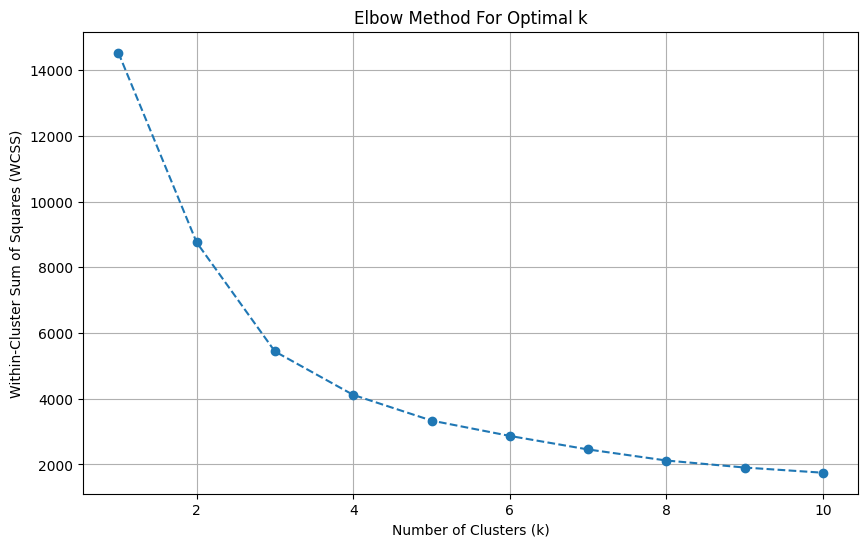

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
max_k = 10 # You can adjust this based on your data and computational resources

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

## KMeans Clustering and Visualization

Next, we will apply the KMeans clustering algorithm. We need to decide on the number of clusters. For demonstration, I will choose `n_clusters=3`. You might want to use methods like the Elbow Method or Silhouette Score to find an optimal number of clusters for your specific data.

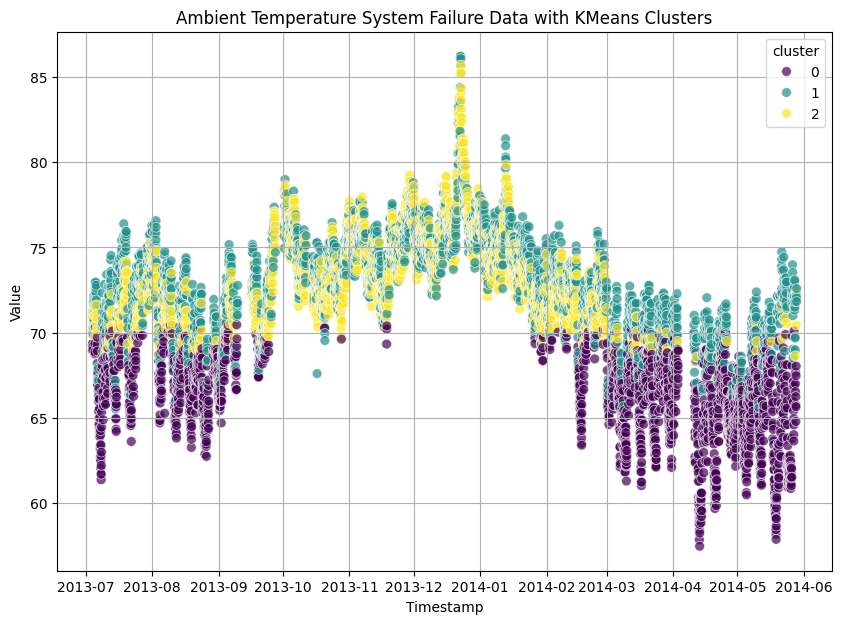

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init is set to suppress warning
df['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='timestamp', y='value', hue='cluster', data=df, palette='viridis', s=50, alpha=0.7)
plt.title('Ambient Temperature System Failure Data with KMeans Clusters')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [13]:
import joblib
from google.colab import files

# 1. Export the trained KMeans model to a pkl file
joblib.dump(kmeans, 'kmeans_anomaly_model.pkl')

# 2. Export the fitted StandardScaler to a pkl file
joblib.dump(scaler, 'data_scaler.pkl')

print("Files successfully generated!")
print("Downloading files to your local computer now...")

# 3. Automatically trigger browser downloads for both files
files.download('kmeans_anomaly_model.pkl')
files.download('data_scaler.pkl')

Files successfully generated!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>